In [1]:
import numpy as np
from numpy import cos, sin
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.patches import Circle
mu = 1.2150584270572e-2
mu_earth = 398600.4418
r_earth = 6378.137

In [2]:
# Example Save Code
# np.savez(
#     "3dorbit",
#     state = state,
#     time = time,
#     control = control,
#     time_c = time_c,
# )
# As long as the save file has state and time, this code will work. Edit the name to match the file of interest. Note that this code in its current state assumes that the state is in the nondimensionalized rotating frame.

file_name = "3dorbit_inertial"
path_modifier = "../Inertial_Cycler_Data/"
reference_name = path_modifier + file_name + ".npz"
orbit = np.load(reference_name)
x, y, z, vx, vy, vz = orbit["state"]
time = orbit["time"]

In [3]:
def aerocapture(data, tgt_alt = 125):
    x, y, z, vx, vy, vz = data["state"]
    time = data["time"]
    combined_state = data["combined_state"]
    r_tgt = r_earth + tgt_alt

    r1 = np.abs(x[0] - combined_state[0,0])
    a_trns = (r1 + r_tgt)/2
    v1 = np.sqrt(mu_earth*(2/r1 - 1/a_trns))

    delta_v = v1 - np.abs(vy[0])
    
    return delta_v, v1

In [4]:
delta_v, v1 = aerocapture(orbit)

In [5]:
vy_rot = x[0]*2*np.pi/27.321661/86400

x_processed = x[0]/384400
vy_processed = (vy[0] - delta_v - vy_rot)*86400/384400*27.321661/(2*np.pi)

In [6]:
def three_body(t, vec):
    x, y, z, vx, vy, vz = vec

    # Equations of Motion
    r1 = np.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

    ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
    ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx
    az = -(1 - mu)*z/r1**3 - mu*z/r2**3

    # System of first-order ODEs
    xdot = vx
    ydot = vy
    zdot = vz
    vxdot = ax
    vydot = ay
    vzdot = az

    return [xdot, ydot, zdot, vxdot, vydot, vzdot]

In [7]:
vec0 = test = np.array([x_processed, 0, 0, 0, vy_processed, 0])
t_span = [0, 0.7593784022067364]

rtol = 1e-14
atol = 1e-24

ivp_sol = solve_ivp(three_body, t_span, vec0, t_eval=None, method='DOP853', rtol=rtol, atol=atol)

c:\Users\Connor Emmons\MIT\Research Projects\Thesis\Code\.venv\Lib\site-packages\scipy\integrate\_ivp\rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


In [8]:
xtr, ytr, ztr, vxtr, vytr, vztr = ivp_sol.y

In [9]:
mu = 1.2150584270572e-2

def t_to_day(t):
    return t*27.321661/2/np.pi

def day_to_t(t):
    return t*2*np.pi/27.321661

def x_to_dist(x):
    return x*384400

def unit_convert(x):
    x_new = np.zeros(np.shape(x))
    for i in range(np.shape(x)[1]):
        x_new[0:3,i] = x_to_dist(x[0:3,i])
        x_new[3:6,i] = day_to_t(x_to_dist(x[3:6,i]))/86400
    return x_new

def rotate_state(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            vx*cos(theta) - vy*sin(theta),
            vx*sin(theta) + vy*cos(theta),
            vz])
    return state_inertial

def rotate_state2(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            (vx - y)*cos(theta) - (vy + x)*sin(theta),
            (vx - y)*sin(theta) + (vy + x)*cos(theta),
            vz])
    return unit_convert(state_inertial)

In [10]:
print(delta_v)
t_to_day(ivp_sol.t[-1] - ivp_sol.t[0])

-0.8037302271683084


np.float64(3.302063883442471)

In [11]:
xt, yt, zt, vxt, vyt, vzt = rotate_state2(ivp_sol.y, ivp_sol.t + day_to_t(time[-1]))

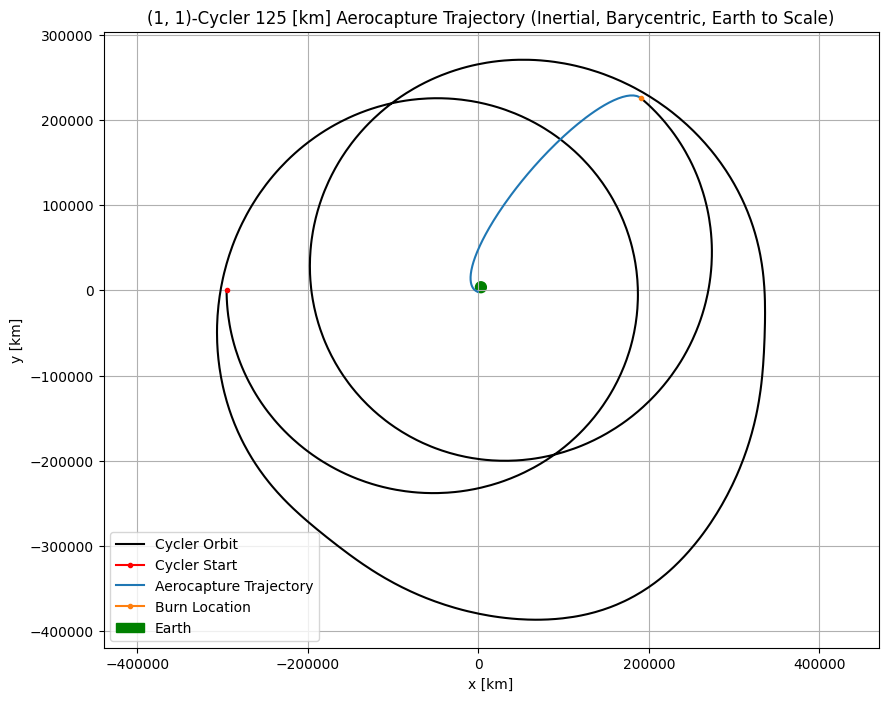

In [12]:
fig = plt.figure(figsize=(10,8))
fig.tight_layout()

ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(x, y, color='black', label='Cycler Orbit')
ax1.plot(x[0], y[0], marker='.', color='red', label='Cycler Start')
ax1.plot(xt, yt, label='Aerocapture Trajectory')
ax1.plot(x[-1], y[-1], marker='.', label='Burn Location')
earth = Circle((orbit["combined_state"][0:2, -1]), 6378.137, label='Earth', color='Green')
ax1.add_patch(earth)
ax1.axis("equal")
ax1.set_xlabel("x [km]")
ax1.set_ylabel("y [km]")
ax1.set_title("(1, 1)-Cycler 125 [km] Aerocapture Trajectory (Inertial, Barycentric, Earth to Scale)")
ax1.legend()
ax1.grid(True)